# Interactive Demo: MLE vs MAP Estimation with Coin Tosses

## Introduction

This interactive demonstration explores the fundamental differences between **Maximum Likelihood Estimation (MLE)** and **Maximum A Posteriori (MAP)** estimation using the classic coin toss example.

### Learning Objectives

By the end of this demo, you will understand:
1. How MLE and MAP differ in their approach to parameter estimation
2. The role of prior beliefs in Bayesian estimation
3. How sample size affects the reliability of estimates
4. When to choose MLE vs MAP in practice

### The Scenario

🪙 **The Problem**: You have a coin with unknown probability $p$ of landing heads. After observing some coin tosses, how do you estimate $p$?

**Two Approaches**:
- **MLE**: Find $p$ that makes the observed data most likely
- **MAP**: Find $p$ that is most probable given the data AND your prior beliefs

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
np.random.seed(42)

# Enable inline plots
%matplotlib inline

/Users/shivin/miniconda/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Mathematical Foundation

### Maximum Likelihood Estimation (MLE)

Given $n$ coin tosses with $h$ heads and $t$ tails:

**Likelihood**: $L(p) = p^h (1-p)^t$

**MLE Solution**: $\hat{p}_{MLE} = \frac{h}{n} = \frac{h}{h+t}$

### Maximum A Posteriori (MAP) Estimation

**Bayes' Theorem**: $P(p|\text{data}) \propto P(\text{data}|p) \times P(p)$

**Prior**: $P(p) = \text{Beta}(\alpha, \beta)$

**Posterior**: $P(p|\text{data}) = \text{Beta}(\alpha + h, \beta + t)$

**MAP Solution**: $\hat{p}_{MAP} = \frac{\alpha + h - 1}{\alpha + \beta + n - 2}$ (for $\alpha, \beta > 1$)

**Simplified MAP**: $\hat{p}_{MAP} = \frac{\alpha + h}{\alpha + \beta + n}$ (mode approximation)

In [2]:
class CoinTossAnalyzer:
    """Class to analyze coin toss data using MLE and MAP."""
    
    def __init__(self):
        self.tosses = []
        self.n_heads = 0
        self.n_tails = 0
        self.n_total = 0
    
    def add_tosses(self, sequence):
        """Add a sequence of coin tosses (H/T or 1/0)."""
        if isinstance(sequence, str):
            # Convert H/T string to list
            sequence = [1 if x.upper() == 'H' else 0 for x in sequence if x.upper() in 'HT']
        
        self.tosses.extend(sequence)
        self.n_heads = sum(self.tosses)
        self.n_tails = len(self.tosses) - self.n_heads
        self.n_total = len(self.tosses)
    
    def reset(self):
        """Reset all data."""
        self.tosses = []
        self.n_heads = 0
        self.n_tails = 0
        self.n_total = 0
    
    def generate_tosses(self, n_tosses, true_p=0.5):
        """Generate random coin tosses."""
        tosses = np.random.binomial(1, true_p, n_tosses)
        self.add_tosses(tosses)
        return tosses
    
    def mle_estimate(self):
        """Calculate MLE estimate."""
        if self.n_total == 0:
            return 0.5  # Default when no data
        return self.n_heads / self.n_total
    
    def map_estimate(self, alpha=1, beta=1):
        """Calculate MAP estimate with Beta(alpha, beta) prior."""
        if self.n_total == 0:
            return alpha / (alpha + beta)  # Prior mean
        return (alpha + self.n_heads) / (alpha + beta + self.n_total)
    
    def likelihood(self, p_values):
        """Calculate likelihood function."""
        if self.n_total == 0:
            return np.ones_like(p_values)
        return (p_values ** self.n_heads) * ((1 - p_values) ** self.n_tails)
    
    def prior(self, p_values, alpha=1, beta=1):
        """Calculate prior probability."""
        return stats.beta.pdf(p_values, alpha, beta)
    
    def posterior(self, p_values, alpha=1, beta=1):
        """Calculate posterior probability."""
        return stats.beta.pdf(p_values, alpha + self.n_heads, beta + self.n_tails)
    
    def credible_interval(self, alpha_param=1, beta_param=1, confidence=0.95):
        """Calculate Bayesian credible interval."""
        alpha_post = alpha_param + self.n_heads
        beta_post = beta_param + self.n_tails
        
        lower = (1 - confidence) / 2
        upper = 1 - lower
        
        return stats.beta.ppf([lower, upper], alpha_post, beta_post)
    
    def summary_stats(self, alpha=1, beta=1):
        """Get summary statistics."""
        mle = self.mle_estimate()
        map_est = self.map_estimate(alpha, beta)
        ci = self.credible_interval(alpha, beta)
        
        return {
            'n_tosses': self.n_total,
            'n_heads': self.n_heads,
            'n_tails': self.n_tails,
            'mle_estimate': mle,
            'map_estimate': map_est,
            'credible_interval': ci,
            'prior_mean': alpha / (alpha + beta)
        }

# Initialize analyzer
analyzer = CoinTossAnalyzer()
print("Coin Toss Analyzer initialized!")

Coin Toss Analyzer initialized!


## Interactive Exploration

### Part 1: Understanding Priors

Before looking at data, let's explore different prior beliefs about the coin's fairness.

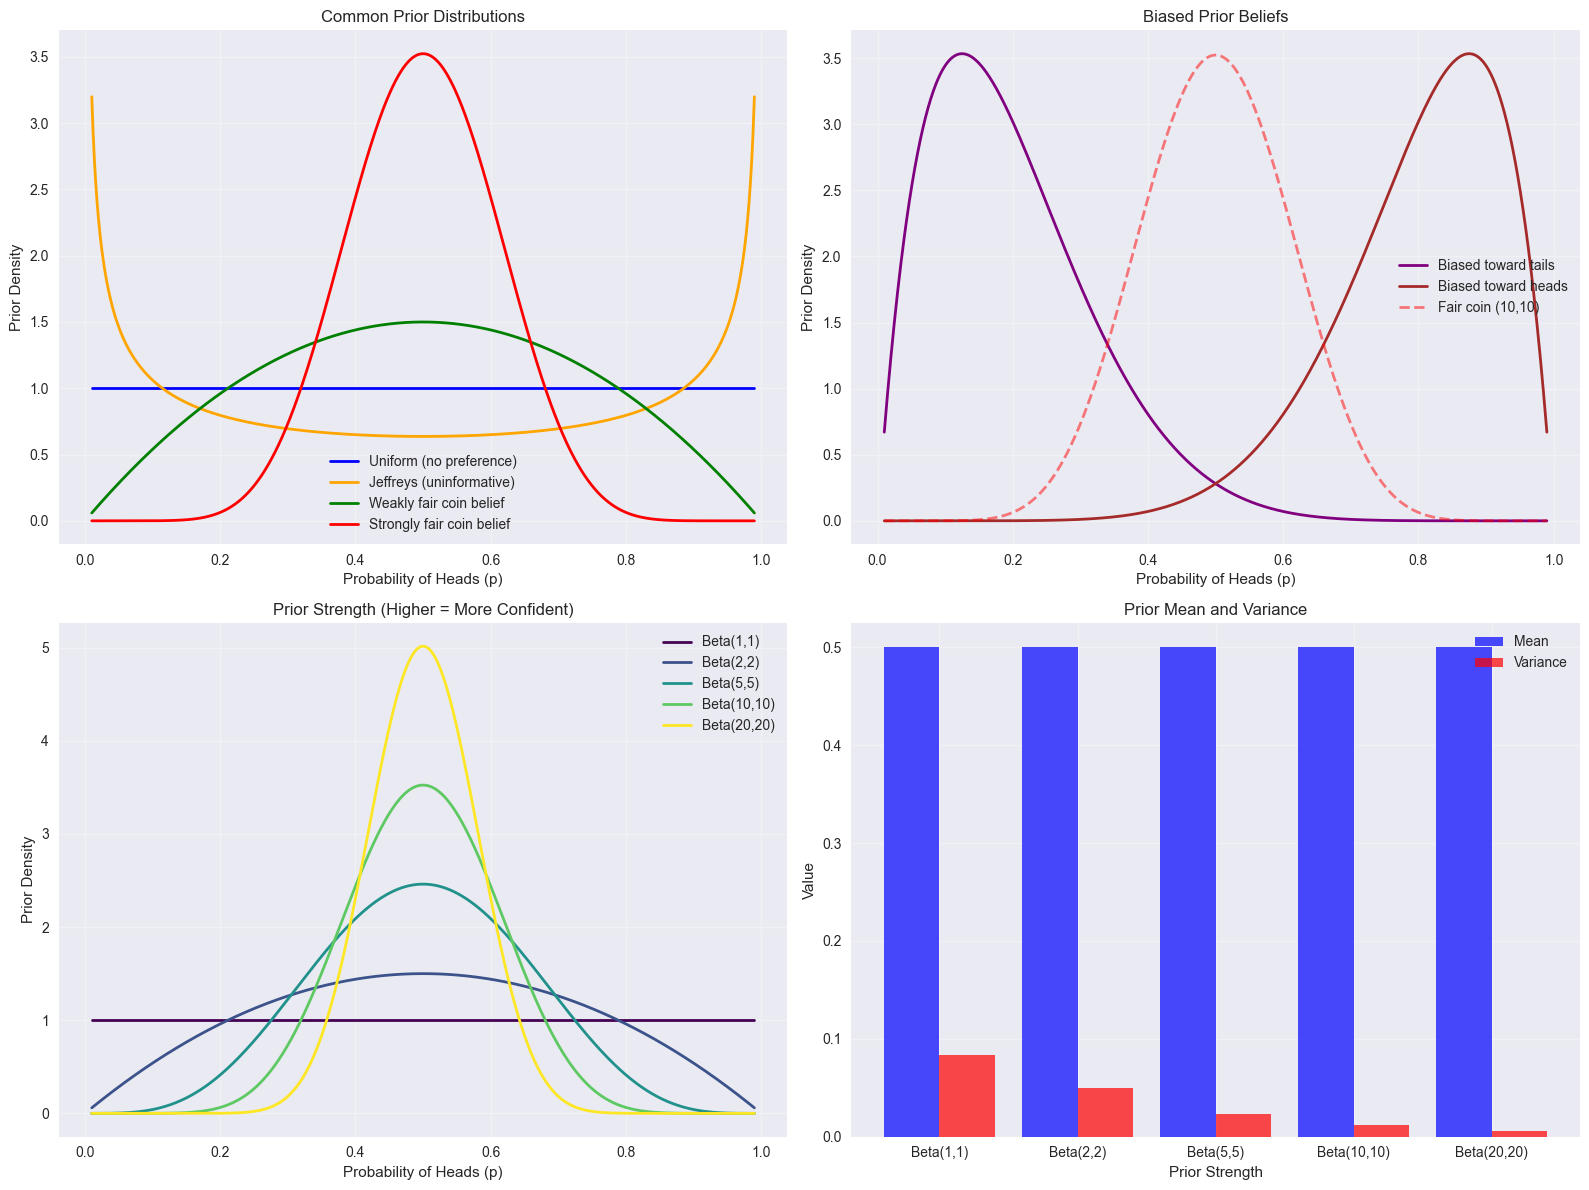

Prior Interpretation Guide:
• Beta(1,1): Uniform - all values equally likely
• Beta(α,α) where α>1: Symmetric around 0.5, confidence = α+β-2
• Beta(α,β) where α>β: Believes coin is biased toward heads
• Beta(α,β) where α<β: Believes coin is biased toward tails
• Larger α+β: Stronger prior belief (more concentrated distribution)


In [3]:
def plot_beta_priors():
    # Plot different Beta priors to show various beliefs
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    p_values = np.linspace(0.01, 0.99, 1000)
    
    # Different priors
    priors = [
        (1, 1, 'Uniform (no preference)', 'blue'),
        (0.5, 0.5, 'Jeffreys (uninformative)', 'orange'),
        (2, 2, 'Weakly fair coin belief', 'green'),
        (10, 10, 'Strongly fair coin belief', 'red'),
        (2, 8, 'Biased toward tails', 'purple'),
        (8, 2, 'Biased toward heads', 'brown')
    ]
    
    # Plot 1: Common priors
    for alpha, beta, label, color in priors[:4]:
        prior_vals = stats.beta.pdf(p_values, alpha, beta)
        ax1.plot(p_values, prior_vals, linewidth=2, label=label, color=color)
    
    ax1.set_xlabel('Probability of Heads (p)')
    ax1.set_ylabel('Prior Density')
    ax1.set_title('Common Prior Distributions')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Biased priors
    for alpha, beta, label, color in priors[4:]:
        prior_vals = stats.beta.pdf(p_values, alpha, beta)
        ax2.plot(p_values, prior_vals, linewidth=2, label=label, color=color)
    
    # Add fair coin for comparison
    fair_prior = stats.beta.pdf(p_values, 10, 10)
    ax2.plot(p_values, fair_prior, '--', linewidth=2, label='Fair coin (10,10)', color='red', alpha=0.5)
    
    ax2.set_xlabel('Probability of Heads (p)')
    ax2.set_ylabel('Prior Density')
    ax2.set_title('Biased Prior Beliefs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Prior strength comparison
    strengths = [(1, 1), (2, 2), (5, 5), (10, 10), (20, 20)]
    colors_strength = plt.cm.viridis(np.linspace(0, 1, len(strengths)))
    
    for i, (alpha, beta) in enumerate(strengths):
        prior_vals = stats.beta.pdf(p_values, alpha, beta)
        ax3.plot(p_values, prior_vals, linewidth=2, 
                label=f'Beta({alpha},{beta})', color=colors_strength[i])
    
    ax3.set_xlabel('Probability of Heads (p)')
    ax3.set_ylabel('Prior Density')
    ax3.set_title('Prior Strength (Higher = More Confident)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Prior statistics
    alpha_vals = [1, 2, 5, 10, 20]
    beta_vals = [1, 2, 5, 10, 20]  # Same as alpha for fair coin
    
    means = [a/(a+b) for a, b in zip(alpha_vals, beta_vals)]
    variances = [a*b/((a+b)**2*(a+b+1)) for a, b in zip(alpha_vals, beta_vals)]
    
    x_pos = range(len(alpha_vals))
    ax4.bar([x-0.2 for x in x_pos], means, 0.4, label='Mean', alpha=0.7, color='blue')
    ax4.bar([x+0.2 for x in x_pos], variances, 0.4, label='Variance', alpha=0.7, color='red')
    
    ax4.set_xlabel('Prior Strength')
    ax4.set_ylabel('Value')
    ax4.set_title('Prior Mean and Variance')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([f'Beta({a},{b})' for a, b in zip(alpha_vals, beta_vals)])
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print interpretation guide
    print("Prior Interpretation Guide:")
    print("=" * 40)
    print("• Beta(1,1): Uniform - all values equally likely")
    print("• Beta(α,α) where α>1: Symmetric around 0.5, confidence = α+β-2")
    print("• Beta(α,β) where α>β: Believes coin is biased toward heads")
    print("• Beta(α,β) where α<β: Believes coin is biased toward tails")
    print("• Larger α+β: Stronger prior belief (more concentrated distribution)")

plot_beta_priors()

### Part 2: Data Generation and Analysis

Now let's generate some coin toss data and see how MLE and MAP estimates compare.

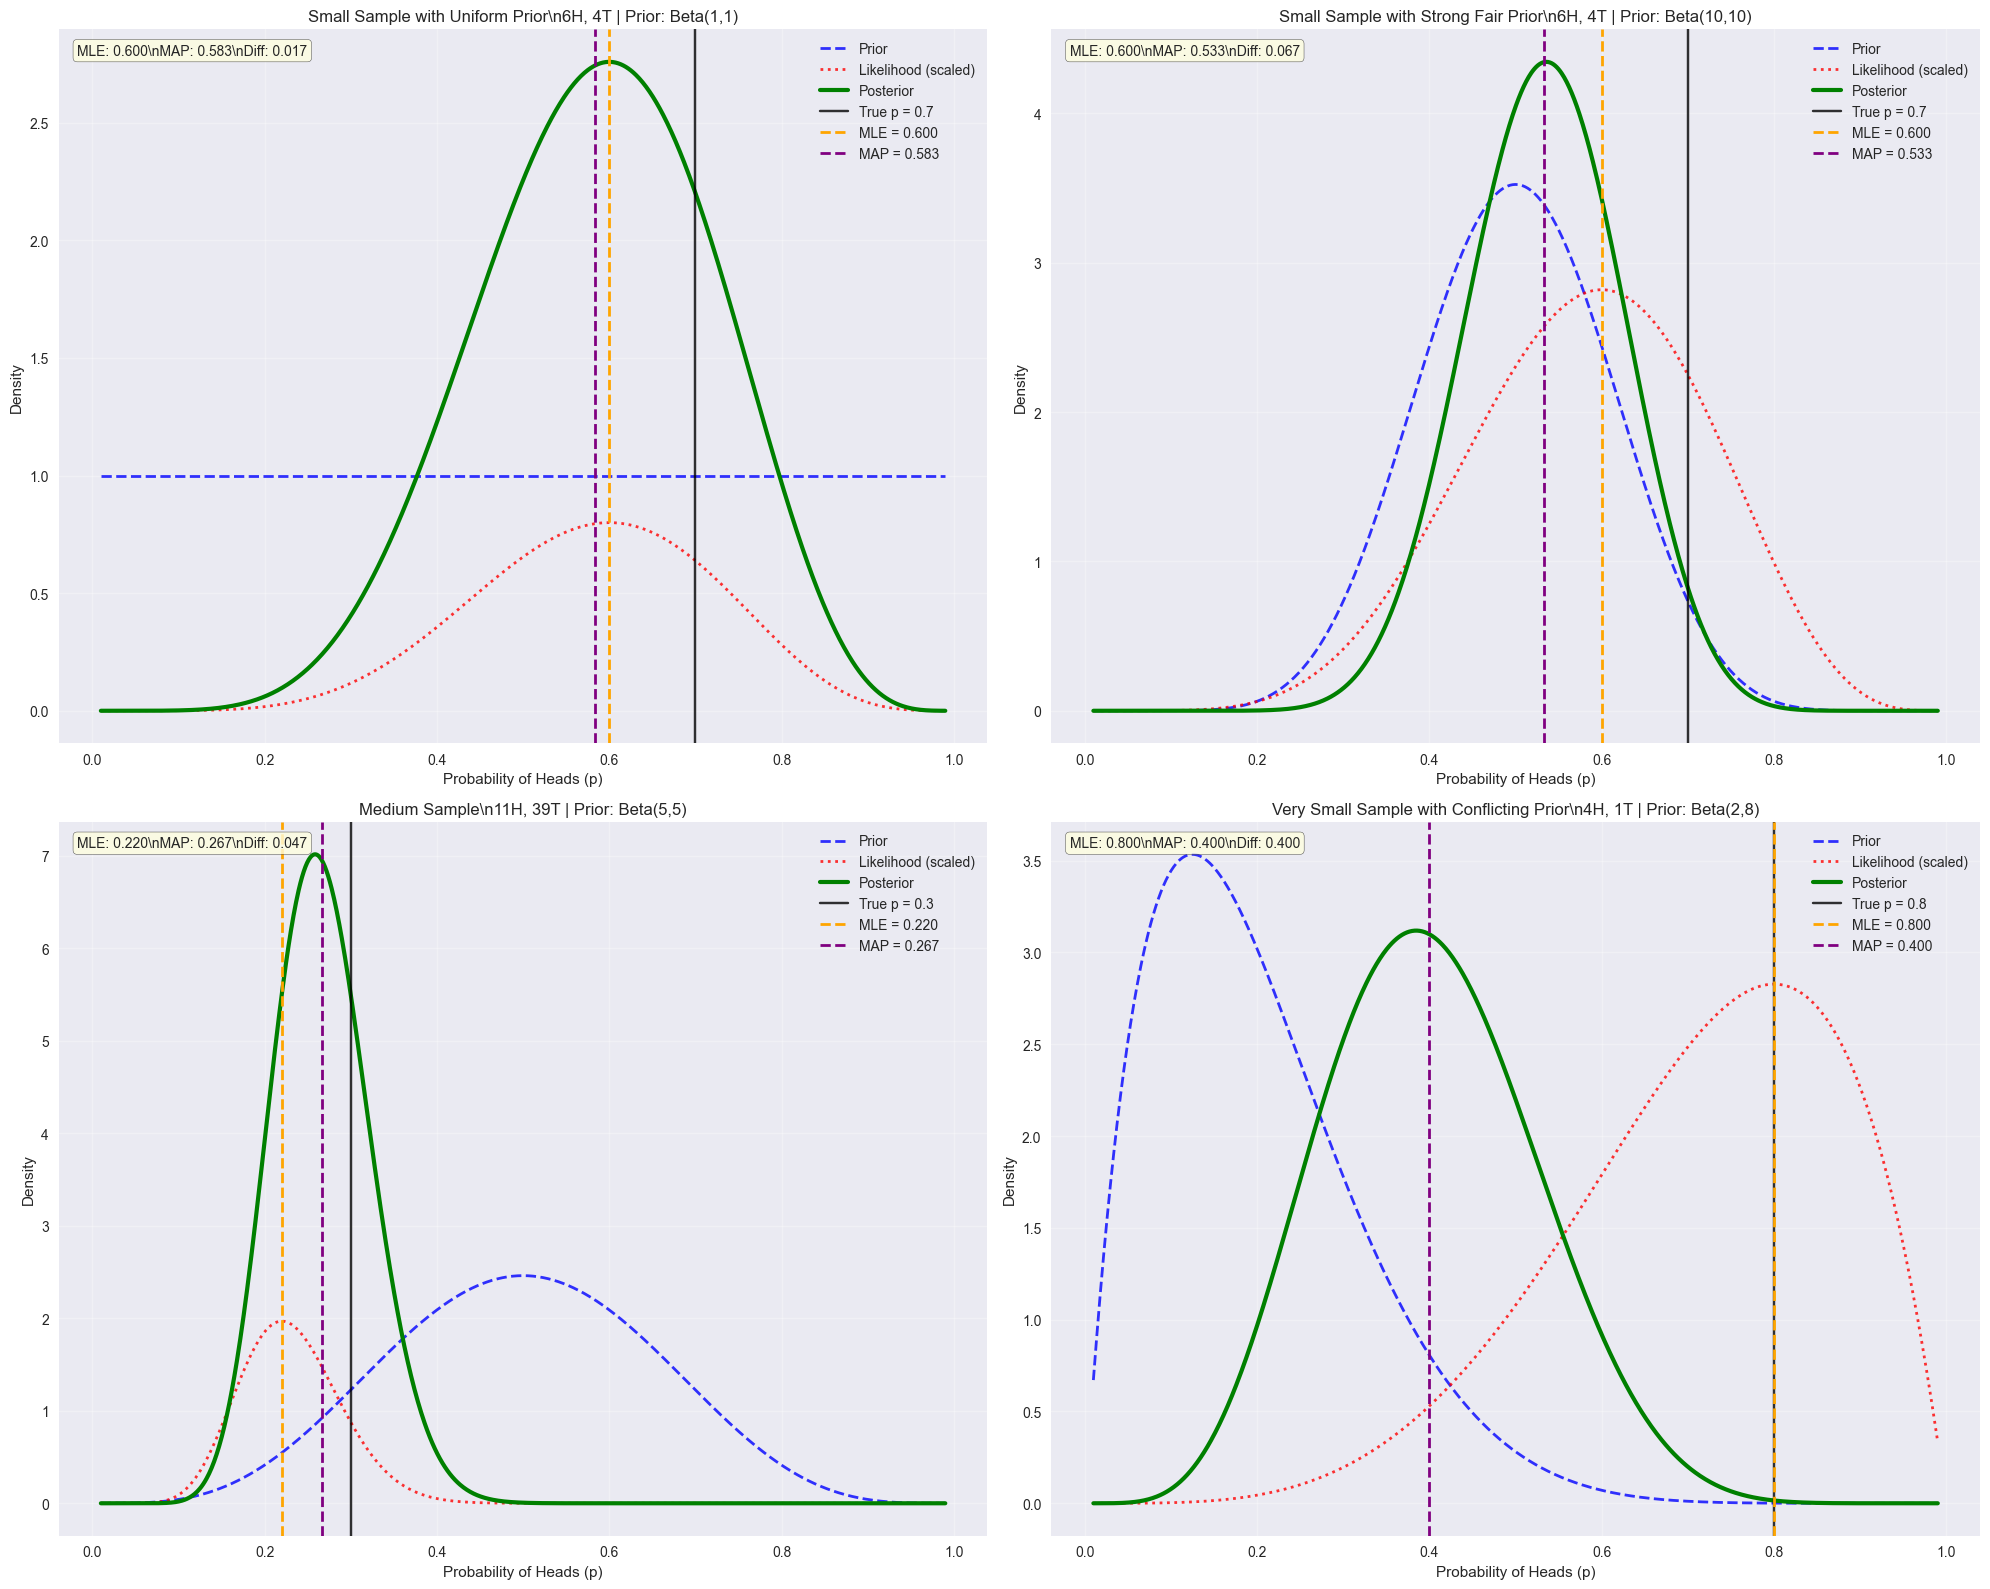

\nSUMMARY OF EXAMPLES
\n1. Small Sample with Uniform Prior:
   Data: 6 heads out of 10 tosses (true p = 0.7)
   Prior: Beta(1, 1) with mean 0.500
   MLE: 0.600 | MAP: 0.583
   Error - MLE: 0.100 | MAP: 0.117
   → MLE and MAP are very similar
\n2. Small Sample with Strong Fair Prior:
   Data: 6 heads out of 10 tosses (true p = 0.7)
   Prior: Beta(10, 10) with mean 0.500
   MLE: 0.600 | MAP: 0.533
   Error - MLE: 0.100 | MAP: 0.167
   → MLE is closer to truth (prior hurts)
\n3. Medium Sample:
   Data: 11 heads out of 50 tosses (true p = 0.3)
   Prior: Beta(5, 5) with mean 0.500
   MLE: 0.220 | MAP: 0.267
   Error - MLE: 0.080 | MAP: 0.033
   → MAP is closer to truth (prior helps!)
\n4. Very Small Sample with Conflicting Prior:
   Data: 4 heads out of 5 tosses (true p = 0.8)
   Prior: Beta(2, 8) with mean 0.200
   MLE: 0.800 | MAP: 0.400
   Error - MLE: 0.000 | MAP: 0.400
   → MLE is closer to truth (prior hurts)


In [4]:
def demonstration_examples():
    """Show several examples of MLE vs MAP estimation."""
    
    # Example scenarios to demonstrate
    scenarios = [
        {'n_tosses': 10, 'true_p': 0.7, 'alpha': 1, 'beta': 1, 'seed': 42, 'title': 'Small Sample with Uniform Prior'},
        {'n_tosses': 10, 'true_p': 0.7, 'alpha': 10, 'beta': 10, 'seed': 42, 'title': 'Small Sample with Strong Fair Prior'},
        {'n_tosses': 50, 'true_p': 0.3, 'alpha': 5, 'beta': 5, 'seed': 42, 'title': 'Medium Sample'},
        {'n_tosses': 5, 'true_p': 0.8, 'alpha': 2, 'beta': 8, 'seed': 42, 'title': 'Very Small Sample with Conflicting Prior'}
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    for i, scenario in enumerate(scenarios):
        # Set seed and generate data
        np.random.seed(scenario['seed'])
        analyzer.reset()
        tosses = analyzer.generate_tosses(scenario['n_tosses'], scenario['true_p'])
        
        # Get estimates
        stats_dict = analyzer.summary_stats(scenario['alpha'], scenario['beta'])
        
        ax = axes[i]
        
        # Create subplot with multiple panels
        # We'll create a more complex visualization in the main axis
        p_range = np.linspace(0.01, 0.99, 1000)
        
        prior_vals = analyzer.prior(p_range, scenario['alpha'], scenario['beta'])
        likelihood_vals = analyzer.likelihood(p_range)
        posterior_vals = analyzer.posterior(p_range, scenario['alpha'], scenario['beta'])
        
        # Normalize likelihood for plotting
        if np.max(likelihood_vals) > 0:
            likelihood_norm = likelihood_vals / np.max(likelihood_vals) * np.max(prior_vals) * 0.8
        else:
            likelihood_norm = likelihood_vals
        
        ax.plot(p_range, prior_vals, 'b--', linewidth=2, label='Prior', alpha=0.8)
        ax.plot(p_range, likelihood_norm, 'r:', linewidth=2, label='Likelihood (scaled)', alpha=0.8)
        ax.plot(p_range, posterior_vals, 'g-', linewidth=3, label='Posterior')
        
        # Mark estimates
        ax.axvline(scenario['true_p'], color='black', linestyle='-', alpha=0.8, label=f'True p = {scenario["true_p"]}')
        ax.axvline(stats_dict['mle_estimate'], color='orange', linestyle='--', linewidth=2, 
                  label=f'MLE = {stats_dict["mle_estimate"]:.3f}')
        ax.axvline(stats_dict['map_estimate'], color='purple', linestyle='--', linewidth=2, 
                  label=f'MAP = {stats_dict["map_estimate"]:.3f}')
        
        ax.set_xlabel('Probability of Heads (p)')
        ax.set_ylabel('Density')
        ax.set_title(f'{scenario["title"]}\\n{stats_dict["n_heads"]}H, {stats_dict["n_tails"]}T | Prior: Beta({scenario["alpha"]},{scenario["beta"]})')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add text box with key info
        info_text = f"MLE: {stats_dict['mle_estimate']:.3f}\\nMAP: {stats_dict['map_estimate']:.3f}\\nDiff: {abs(stats_dict['map_estimate'] - stats_dict['mle_estimate']):.3f}"
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=10, 
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print("\\nSUMMARY OF EXAMPLES")
    print("=" * 80)
    
    for i, scenario in enumerate(scenarios):
        np.random.seed(scenario['seed'])
        analyzer.reset()
        analyzer.generate_tosses(scenario['n_tosses'], scenario['true_p'])
        stats_dict = analyzer.summary_stats(scenario['alpha'], scenario['beta'])
        
        print(f"\\n{i+1}. {scenario['title']}:")
        print(f"   Data: {stats_dict['n_heads']} heads out of {stats_dict['n_tosses']} tosses (true p = {scenario['true_p']})")
        print(f"   Prior: Beta({scenario['alpha']}, {scenario['beta']}) with mean {stats_dict['prior_mean']:.3f}")
        print(f"   MLE: {stats_dict['mle_estimate']:.3f} | MAP: {stats_dict['map_estimate']:.3f}")
        print(f"   Error - MLE: {abs(stats_dict['mle_estimate'] - scenario['true_p']):.3f} | MAP: {abs(stats_dict['map_estimate'] - scenario['true_p']):.3f}")
        
        # Interpretation
        if abs(stats_dict['map_estimate'] - stats_dict['mle_estimate']) > 0.02:
            if abs(stats_dict['map_estimate'] - scenario['true_p']) < abs(stats_dict['mle_estimate'] - scenario['true_p']):
                print(f"   → MAP is closer to truth (prior helps!)")
            else:
                print(f"   → MLE is closer to truth (prior hurts)")
        else:
            print(f"   → MLE and MAP are very similar")

demonstration_examples()

### Part 3: Evolution of Estimates

Let's see how estimates change as we collect more data.

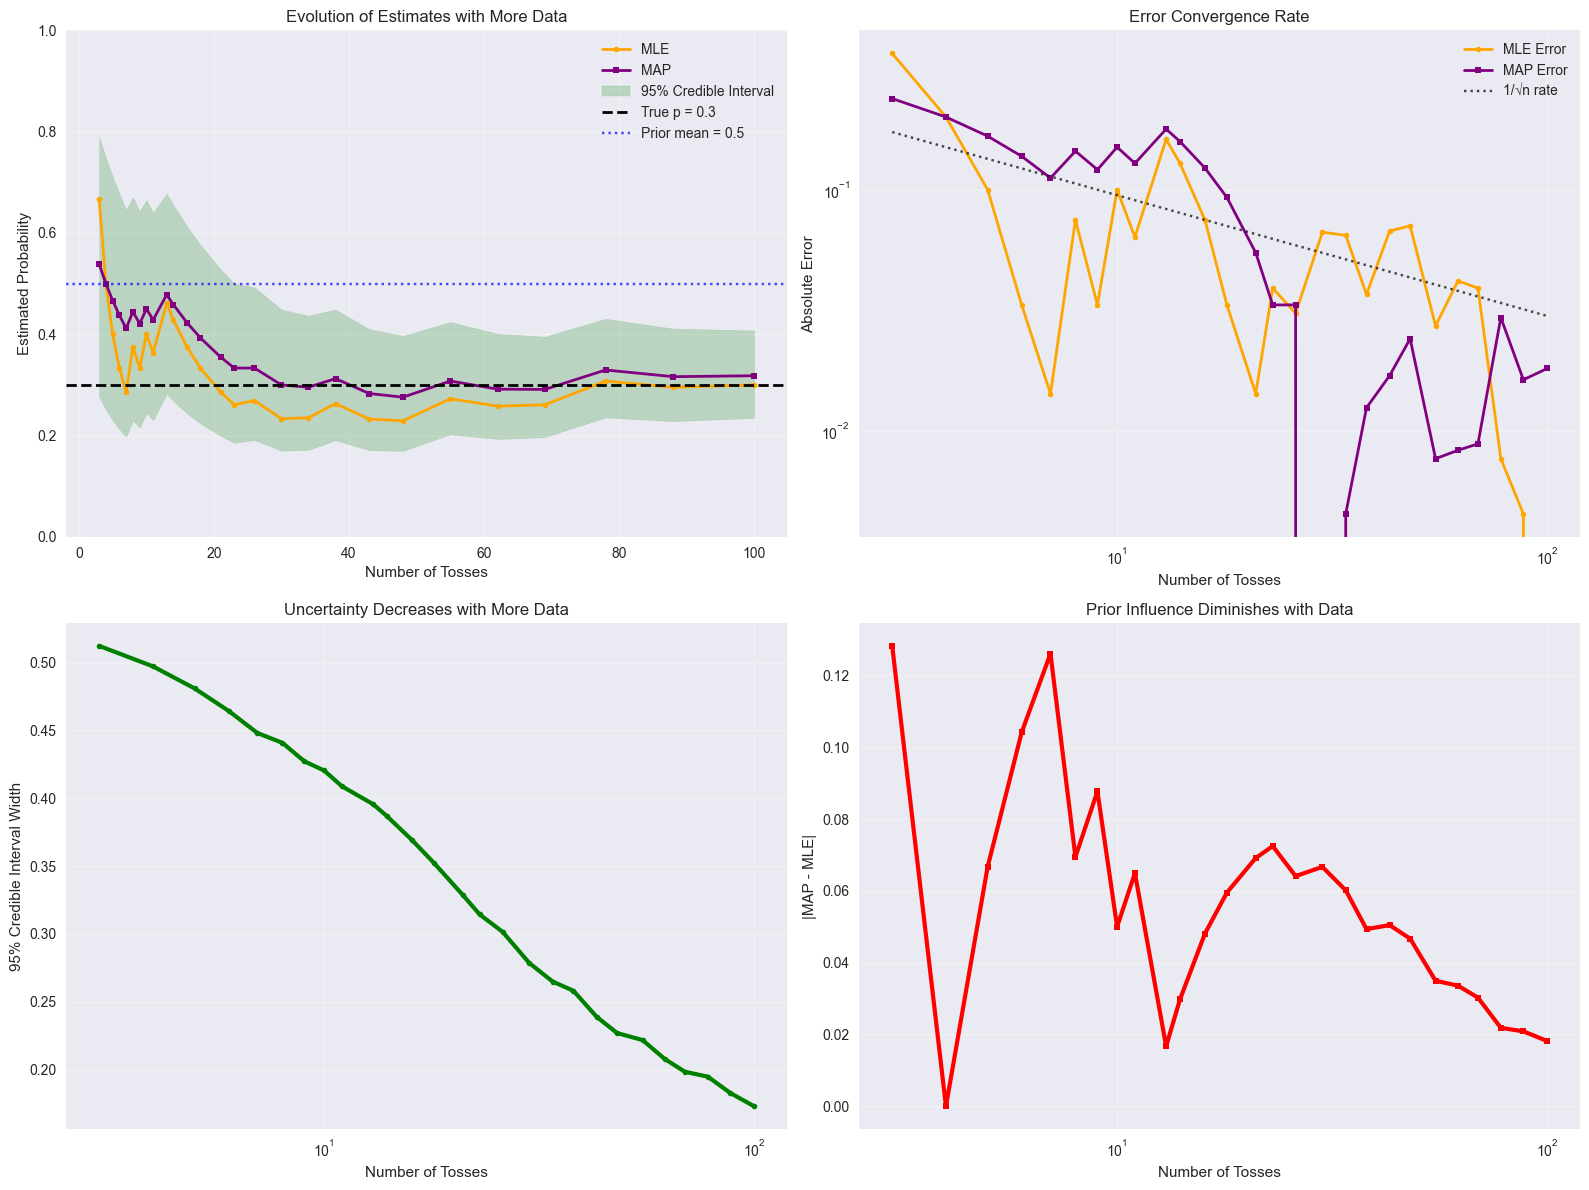

Evolution Analysis (True p = 0.3, Prior = Beta(5,5)):
After  5 tosses: MLE=0.400, MAP=0.467, CI width=0.481
After 10 tosses: MLE=0.400, MAP=0.450, CI width=0.421
After 26 tosses: MLE=0.269, MAP=0.333, CI width=0.302
After 48 tosses: MLE=0.229, MAP=0.276, CI width=0.227
After 100 tosses: MLE=0.300, MAP=0.318, CI width=0.173
Final comparison:
MLE converges to: 0.300 (error: 0.000)
MAP converges to: 0.318 (error: 0.018)
Prior influence at end: 0.0182


In [5]:
def plot_estimate_evolution():
    """Show how estimates evolve with more data."""
    
    # Fixed parameters for demonstration
    true_p = 0.3
    max_tosses = 100
    alpha, beta = 5, 5  # Moderately strong fair prior
    
    np.random.seed(42)
    all_tosses = np.random.binomial(1, true_p, max_tosses)
    
    # Calculate cumulative estimates
    n_points = 30  # Points to plot
    indices = np.unique(np.logspace(0.5, np.log10(max_tosses), n_points, dtype=int)) - 1
    
    mle_estimates = []
    map_estimates = []
    ci_lower = []
    ci_upper = []
    
    for i in indices:
        tosses_so_far = all_tosses[:i+1]
        n_heads = np.sum(tosses_so_far)
        n_total = len(tosses_so_far)
        
        # MLE
        mle_est = n_heads / n_total
        mle_estimates.append(mle_est)
        
        # MAP
        map_est = (alpha + n_heads) / (alpha + beta + n_total)
        map_estimates.append(map_est)
        
        # Credible interval
        alpha_post = alpha + n_heads
        beta_post = beta + n_total - n_heads
        ci = stats.beta.ppf([0.025, 0.975], alpha_post, beta_post)
        ci_lower.append(ci[0])
        ci_upper.append(ci[1])
    
    # Create comprehensive plot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Evolution of estimates
    ax1.plot(indices + 1, mle_estimates, 'o-', color='orange', linewidth=2, markersize=4, label='MLE')
    ax1.plot(indices + 1, map_estimates, 's-', color='purple', linewidth=2, markersize=4, label='MAP')
    ax1.fill_between(indices + 1, ci_lower, ci_upper, alpha=0.2, color='green', label='95% Credible Interval')
    ax1.axhline(true_p, color='black', linestyle='--', linewidth=2, label=f'True p = {true_p}')
    ax1.axhline(alpha/(alpha+beta), color='blue', linestyle=':', alpha=0.7, label=f'Prior mean = 0.5')
    
    ax1.set_xlabel('Number of Tosses')
    ax1.set_ylabel('Estimated Probability')
    ax1.set_title('Evolution of Estimates with More Data')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)
    
    # Plot 2: Estimation errors (log scale)
    mle_errors = [abs(est - true_p) for est in mle_estimates]
    map_errors = [abs(est - true_p) for est in map_estimates]
    
    ax2.loglog(indices + 1, mle_errors, 'o-', color='orange', linewidth=2, markersize=4, label='MLE Error')
    ax2.loglog(indices + 1, map_errors, 's-', color='purple', linewidth=2, markersize=4, label='MAP Error')
    
    # Theoretical convergence rate
    theoretical = 0.3 / np.sqrt(indices + 1)
    ax2.loglog(indices + 1, theoretical, 'k:', alpha=0.7, label='1/√n rate')
    
    ax2.set_xlabel('Number of Tosses')
    ax2.set_ylabel('Absolute Error')
    ax2.set_title('Error Convergence Rate')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Credible interval width evolution
    ci_widths = [upper - lower for lower, upper in zip(ci_lower, ci_upper)]
    
    ax3.semilogx(indices + 1, ci_widths, 'g-', linewidth=3, marker='o', markersize=4)
    ax3.set_xlabel('Number of Tosses')
    ax3.set_ylabel('95% Credible Interval Width')
    ax3.set_title('Uncertainty Decreases with More Data')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Prior influence over time
    prior_influence = [abs(map_est - mle_est) for map_est, mle_est in zip(map_estimates, mle_estimates)]
    
    ax4.semilogx(indices + 1, prior_influence, 'r-', linewidth=3, marker='s', markersize=4)
    ax4.set_xlabel('Number of Tosses')
    ax4.set_ylabel('|MAP - MLE|')
    ax4.set_title('Prior Influence Diminishes with Data')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print key results
    print(f"Evolution Analysis (True p = {true_p}, Prior = Beta({alpha},{beta})):")
    print("=" * 60)
    
    checkpoints = [5, 10, 25, 50, 100]
    for checkpoint in checkpoints:
        if checkpoint <= max_tosses:
            idx = min(range(len(indices)), key=lambda i: abs(indices[i] + 1 - checkpoint))
            n = indices[idx] + 1
            mle = mle_estimates[idx]
            map_est = map_estimates[idx]
            ci_width = ci_widths[idx]
            
            print(f"After {n:2d} tosses: MLE={mle:.3f}, MAP={map_est:.3f}, CI width={ci_width:.3f}")
    
    print(f"Final comparison:")
    print(f"MLE converges to: {mle_estimates[-1]:.3f} (error: {abs(mle_estimates[-1] - true_p):.3f})")
    print(f"MAP converges to: {map_estimates[-1]:.3f} (error: {abs(map_estimates[-1] - true_p):.3f})")
    print(f"Prior influence at end: {abs(map_estimates[-1] - mle_estimates[-1]):.4f}")

plot_estimate_evolution()

### Part 4: Custom Sequence Examples

Let's analyze several custom coin toss sequences to see how MLE and MAP behave with different patterns and priors.

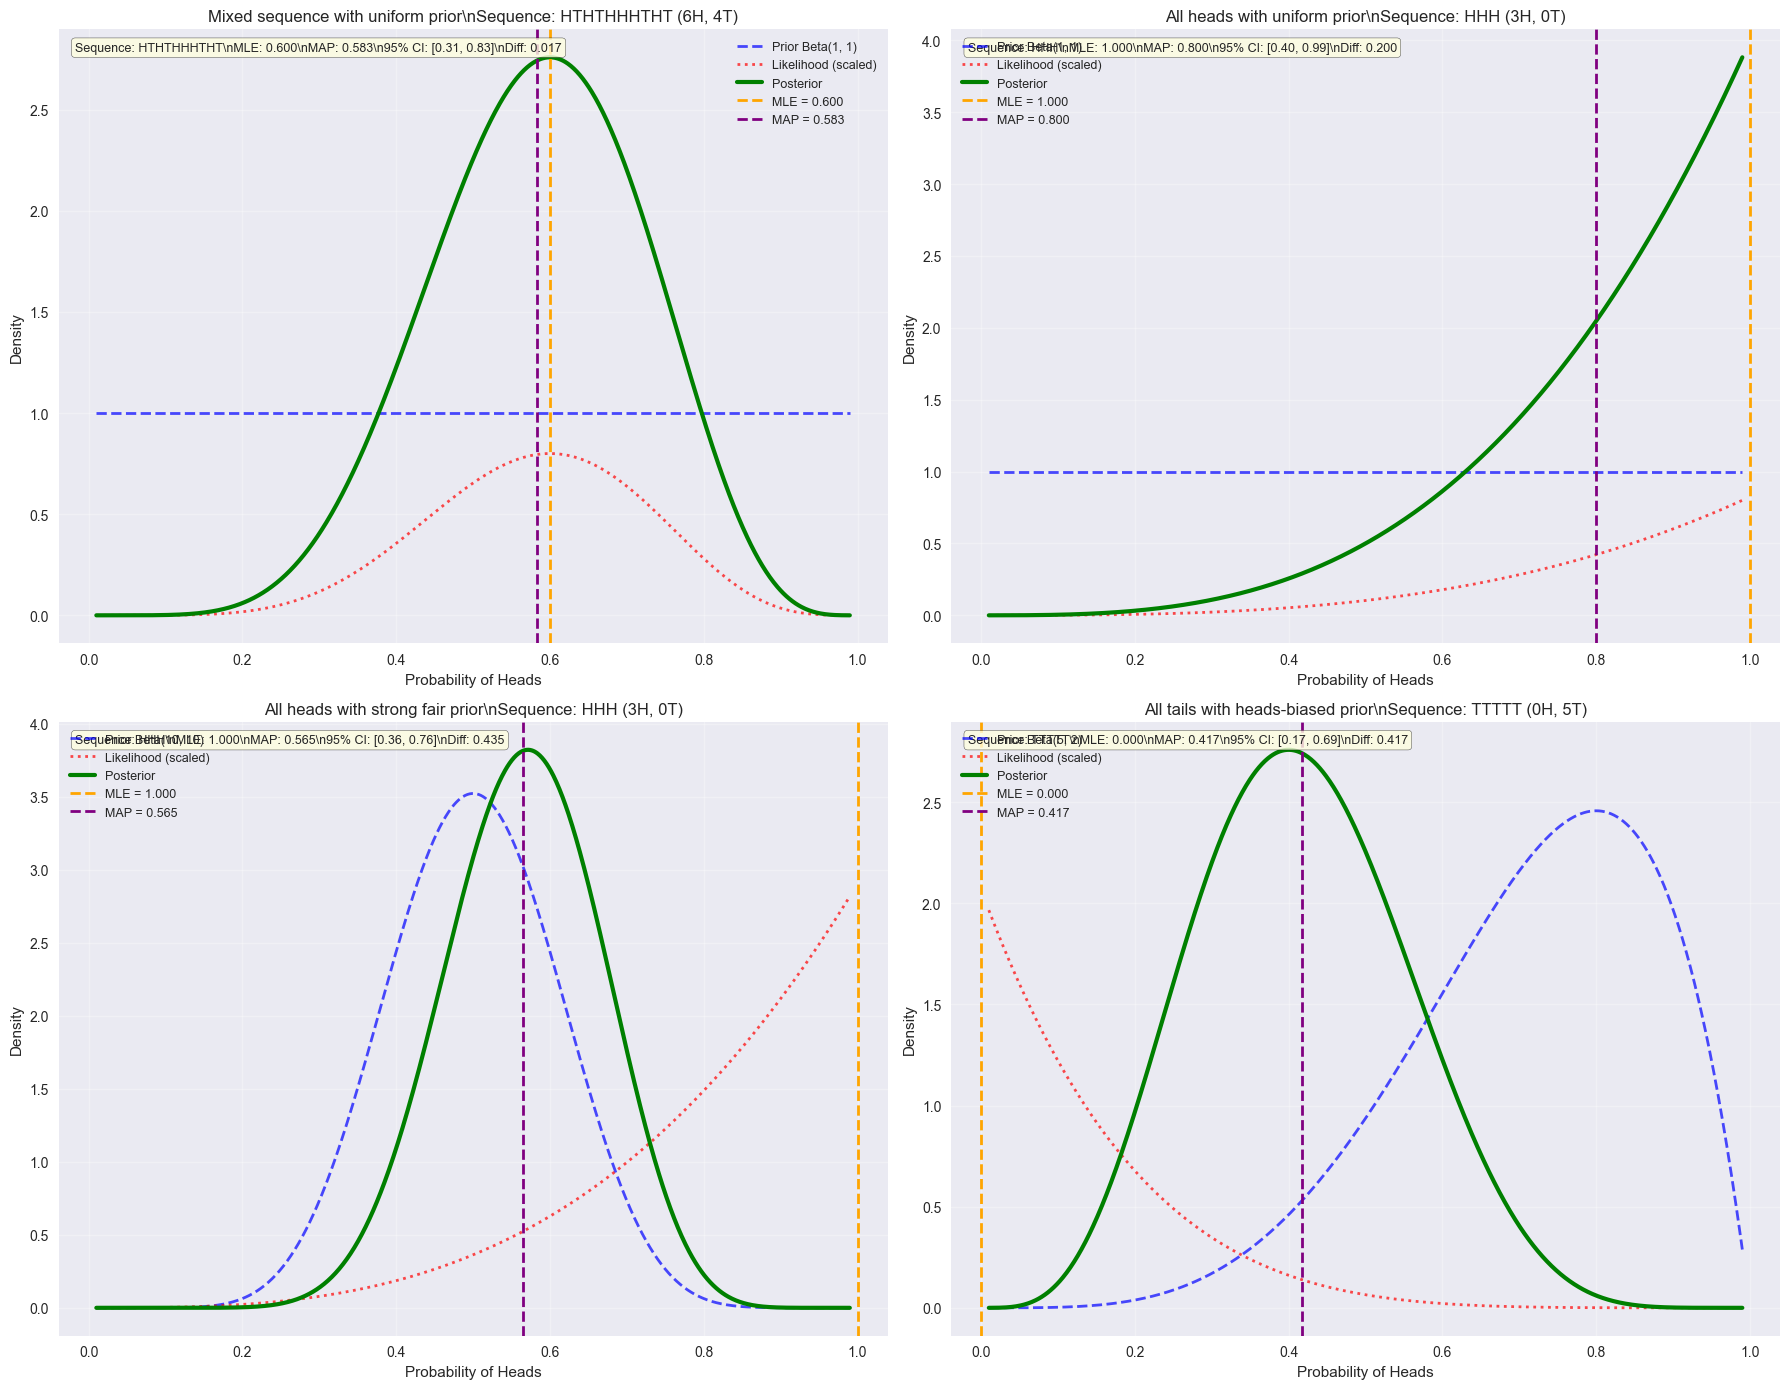

\nDETAILED ANALYSIS OF CUSTOM SEQUENCES
\n1. MIXED SEQUENCE WITH UNIFORM PRIOR
   Sequence: HTHTHHHTHT (Length: 10)
   Outcomes: 6 heads, 4 tails
   Prior: Beta(1, 1) with mean 0.500
   MLE estimate: 0.600
   MAP estimate: 0.583
   Difference (MAP-MLE): -0.017
   95% Credible Interval: [0.308, 0.833] (width: 0.525)
   → Prior influence is minimal
\n2. ALL HEADS WITH UNIFORM PRIOR
   Sequence: HHH (Length: 3)
   Outcomes: 3 heads, 0 tails
   Prior: Beta(1, 1) with mean 0.500
   MLE estimate: 1.000
   MAP estimate: 0.800
   Difference (MAP-MLE): -0.200
   95% Credible Interval: [0.398, 0.994] (width: 0.596)
   → MLE gives extreme estimate, MAP is more conservative
\n3. ALL HEADS WITH STRONG FAIR PRIOR
   Sequence: HHH (Length: 3)
   Outcomes: 3 heads, 0 tails
   Prior: Beta(10, 10) with mean 0.500
   MLE estimate: 1.000
   MAP estimate: 0.565
   Difference (MAP-MLE): -0.435
   95% Credible Interval: [0.364, 0.756] (width: 0.393)
   → Strong fair prior prevents extreme estimate!
\n4. ALL 

In [6]:
def custom_sequence_examples():
    """Analyze several example custom sequences."""
    
    # Example sequences to demonstrate
    examples = [
        {'sequence': 'HTHTHHHTHT', 'alpha': 1, 'beta': 1, 'title': 'Mixed sequence with uniform prior'},
        {'sequence': 'HHH', 'alpha': 1, 'beta': 1, 'title': 'All heads with uniform prior'},
        {'sequence': 'HHH', 'alpha': 10, 'beta': 10, 'title': 'All heads with strong fair prior'},
        {'sequence': 'TTTTT', 'alpha': 5, 'beta': 2, 'title': 'All tails with heads-biased prior'}
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()
    
    for i, example in enumerate(examples):
        sequence = example['sequence']
        alpha = example['alpha']
        beta = example['beta']
        
        # Reset analyzer and add custom sequence
        analyzer.reset()
        analyzer.add_tosses(sequence)
        
        stats_dict = analyzer.summary_stats(alpha, beta)
        ax = axes[i]
        
        # Create subplot with sequence visualization and analysis
        # We'll create an inset for the sequence and main plot for distributions
        
        # Main plot: Prior, likelihood, posterior
        p_range = np.linspace(0.01, 0.99, 1000)
        
        prior_vals = analyzer.prior(p_range, alpha, beta)
        likelihood_vals = analyzer.likelihood(p_range)
        posterior_vals = analyzer.posterior(p_range, alpha, beta)
        
        # Normalize likelihood for plotting
        if np.max(likelihood_vals) > 0:
            likelihood_vals = likelihood_vals / np.max(likelihood_vals) * np.max(prior_vals) * 0.8
        
        ax.plot(p_range, prior_vals, 'b--', linewidth=2, label=f'Prior Beta({alpha}, {beta})', alpha=0.7)
        ax.plot(p_range, likelihood_vals, 'r:', linewidth=2, label='Likelihood (scaled)', alpha=0.7)
        ax.plot(p_range, posterior_vals, 'g-', linewidth=3, label='Posterior')
        
        ax.axvline(stats_dict['mle_estimate'], color='orange', linestyle='--', linewidth=2, 
                  label=f'MLE = {stats_dict["mle_estimate"]:.3f}')
        ax.axvline(stats_dict['map_estimate'], color='purple', linestyle='--', linewidth=2, 
                  label=f'MAP = {stats_dict["map_estimate"]:.3f}')
        
        ax.set_xlabel('Probability of Heads')
        ax.set_ylabel('Density')
        ax.set_title(f'{example["title"]}\\nSequence: {sequence} ({stats_dict["n_heads"]}H, {stats_dict["n_tails"]}T)')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        
        # Add text box with detailed info
        ci = stats_dict['credible_interval']
        info_text = (f"Sequence: {sequence}\\n"
                    f"MLE: {stats_dict['mle_estimate']:.3f}\\n"
                    f"MAP: {stats_dict['map_estimate']:.3f}\\n"
                    f"95% CI: [{ci[0]:.2f}, {ci[1]:.2f}]\\n"
                    f"Diff: {abs(stats_dict['map_estimate'] - stats_dict['mle_estimate']):.3f}")
        
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=9, 
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed analysis for each example
    print("\\nDETAILED ANALYSIS OF CUSTOM SEQUENCES")
    print("=" * 70)
    
    for i, example in enumerate(examples):
        sequence = example['sequence']
        alpha = example['alpha']
        beta = example['beta']
        
        analyzer.reset()
        analyzer.add_tosses(sequence)
        stats_dict = analyzer.summary_stats(alpha, beta)
        ci = stats_dict['credible_interval']
        
        print(f"\\n{i+1}. {example['title'].upper()}")
        print(f"   Sequence: {sequence} (Length: {len(sequence)})")
        print(f"   Outcomes: {stats_dict['n_heads']} heads, {stats_dict['n_tails']} tails")
        print(f"   Prior: Beta({alpha}, {beta}) with mean {stats_dict['prior_mean']:.3f}")
        print(f"   MLE estimate: {stats_dict['mle_estimate']:.3f}")
        print(f"   MAP estimate: {stats_dict['map_estimate']:.3f}")
        print(f"   Difference (MAP-MLE): {stats_dict['map_estimate'] - stats_dict['mle_estimate']:+.3f}")
        print(f"   95% Credible Interval: [{ci[0]:.3f}, {ci[1]:.3f}] (width: {ci[1]-ci[0]:.3f})")
        
        # Interpretation
        if sequence in ['HHH', 'HHHH', 'TTT', 'TTTT']:
            if alpha == beta and alpha > 5:
                print(f"   → Strong fair prior prevents extreme estimate!")
            else:
                print(f"   → MLE gives extreme estimate, MAP is more conservative")
        elif abs(stats_dict['map_estimate'] - stats_dict['mle_estimate']) > 0.05:
            print(f"   → Prior has significant influence on estimate")
        else:
            print(f"   → Prior influence is minimal")
    
    print(f"\\nKEY INSIGHTS:")
    print(f"- Extreme sequences (all H or all T) show biggest MLE vs MAP differences")
    print(f"- Strong priors prevent unrealistic estimates from small samples")
    print(f"- Mixed sequences show less prior influence")
    print(f"- Credible intervals quantify estimation uncertainty")

# Run the custom sequence examples
custom_sequence_examples()

## Learning Exercises

### Exercise 1: Small Sample Behavior
Try the following scenarios with very few tosses (n=3-5) and observe the differences:
1. All heads (HHH) with uniform prior vs strong "fair coin" prior
2. Mixed sequence (HTH) with different prior strengths

**Questions:**
- When does MLE give extreme estimates (0 or 1)? Why is this problematic?
- How does MAP regularize these extreme estimates?
- What happens to the credible interval width with stronger priors?

In [ ]:
# Space for student exploration and answers
print("Exercise 1: Explore small sample behavior")
print("Try sequences like 'HHH', 'TTT', 'HTH' with different priors")
print("")
print("Your observations:")
print("1. MLE extreme estimates occur when:")
print("   [Your answer here]")
print("")
print("2. MAP regularization effect:")
print("   [Your answer here]")
print("")
print("3. Prior strength vs credible interval width:")
print("   [Your answer here]")

### Exercise 2: Prior Sensitivity
Fix a sequence (e.g., 7 heads out of 10 tosses) and vary the prior parameters:
1. Uniform: α=1, β=1
2. Weakly informative: α=2, β=2
3. Strongly biased toward fairness: α=10, β=10
4. Biased toward heads: α=8, β=2

**Questions:**
- How does prior strength affect the MAP estimate?
- At what sample size does the prior become negligible?
- When might you prefer a strong prior vs weak prior?

Fixed sequence: HHHTHTHHTH
MLE estimate: 0.700

Prior Sensitivity Analysis:
           Prior   α   β  Prior Mean  MAP Estimate  Difference from MLE
0        Uniform   1   1         0.5         0.667               -0.033
1    Weakly Fair   2   2         0.5         0.643               -0.057
2  Strongly Fair  10  10         0.5         0.567               -0.133
3   Heads Biased   8   2         0.8         0.750                0.050
4   Tails Biased   2   8         0.2         0.450               -0.250


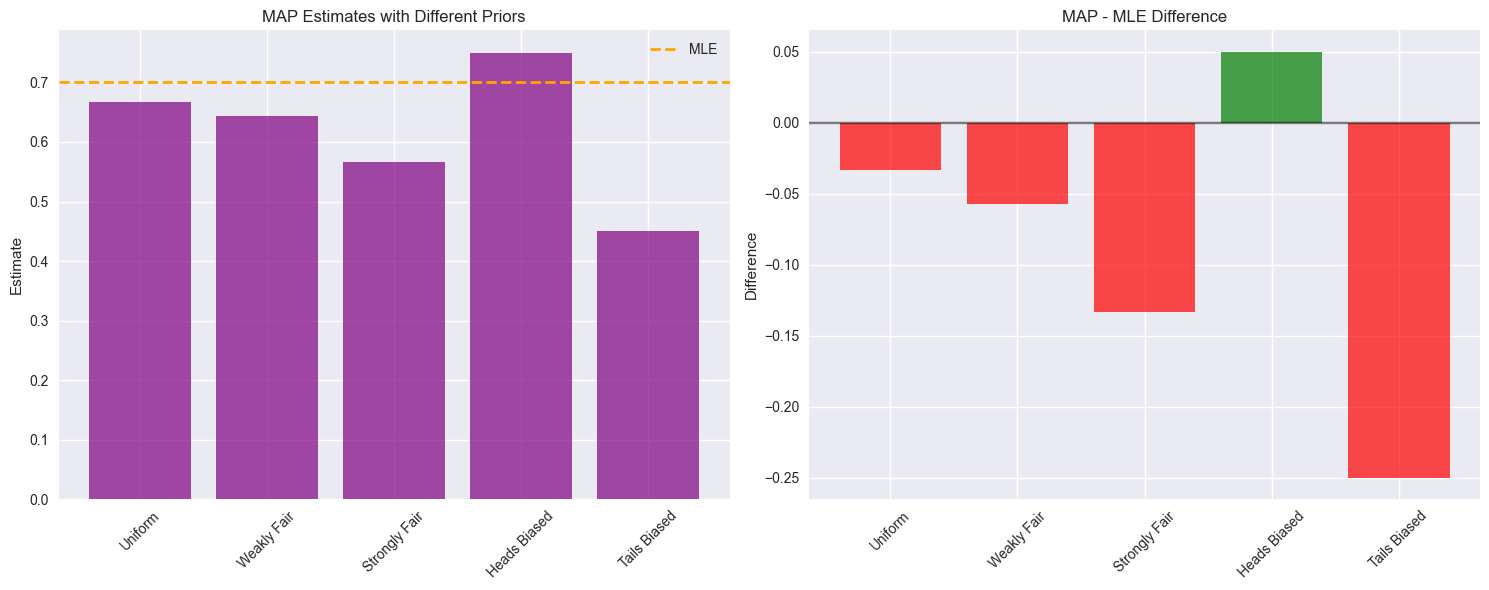

In [19]:
# Systematic prior sensitivity analysis
def prior_sensitivity_experiment():
    """Systematic analysis of prior effects."""
    
    # Fixed sequence: 7 heads out of 10
    fixed_sequence = "HHHTHTHHTH"  # 7H, 3T
    analyzer.reset()
    analyzer.add_tosses(fixed_sequence)
    
    # Different priors to test
    priors = [
        (1, 1, "Uniform"),
        (2, 2, "Weakly Fair"),
        (10, 10, "Strongly Fair"),
        (8, 2, "Heads Biased"),
        (2, 8, "Tails Biased")
    ]
    
    results = []
    for alpha, beta, name in priors:
        stats = analyzer.summary_stats(alpha, beta)
        results.append({
            'Prior': name,
            'α': alpha,
            'β': beta,
            'Prior Mean': alpha/(alpha+beta),
            'MAP Estimate': stats['map_estimate'],
            'Difference from MLE': stats['map_estimate'] - stats['mle_estimate']
        })
    
    df = pd.DataFrame(results)
    print(f"Fixed sequence: {fixed_sequence}")
    print(f"MLE estimate: {analyzer.mle_estimate():.3f}")
    print("\nPrior Sensitivity Analysis:")
    print(df.round(3))
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # MAP estimates
    ax1.bar(df['Prior'], df['MAP Estimate'], alpha=0.7, color='purple')
    ax1.axhline(analyzer.mle_estimate(), color='orange', linestyle='--', linewidth=2, label='MLE')
    ax1.set_title('MAP Estimates with Different Priors')
    ax1.set_ylabel('Estimate')
    ax1.legend()
    ax1.tick_params(axis='x', rotation=45)
    
    # Difference from MLE
    colors = ['green' if x >= 0 else 'red' for x in df['Difference from MLE']]
    ax2.bar(df['Prior'], df['Difference from MLE'], alpha=0.7, color=colors)
    ax2.axhline(0, color='black', linestyle='-', alpha=0.5)
    ax2.set_title('MAP - MLE Difference')
    ax2.set_ylabel('Difference')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

prior_sensitivity_experiment()

### Exercise 3: Convergence Analysis
Study how MLE and MAP converge as sample size increases.

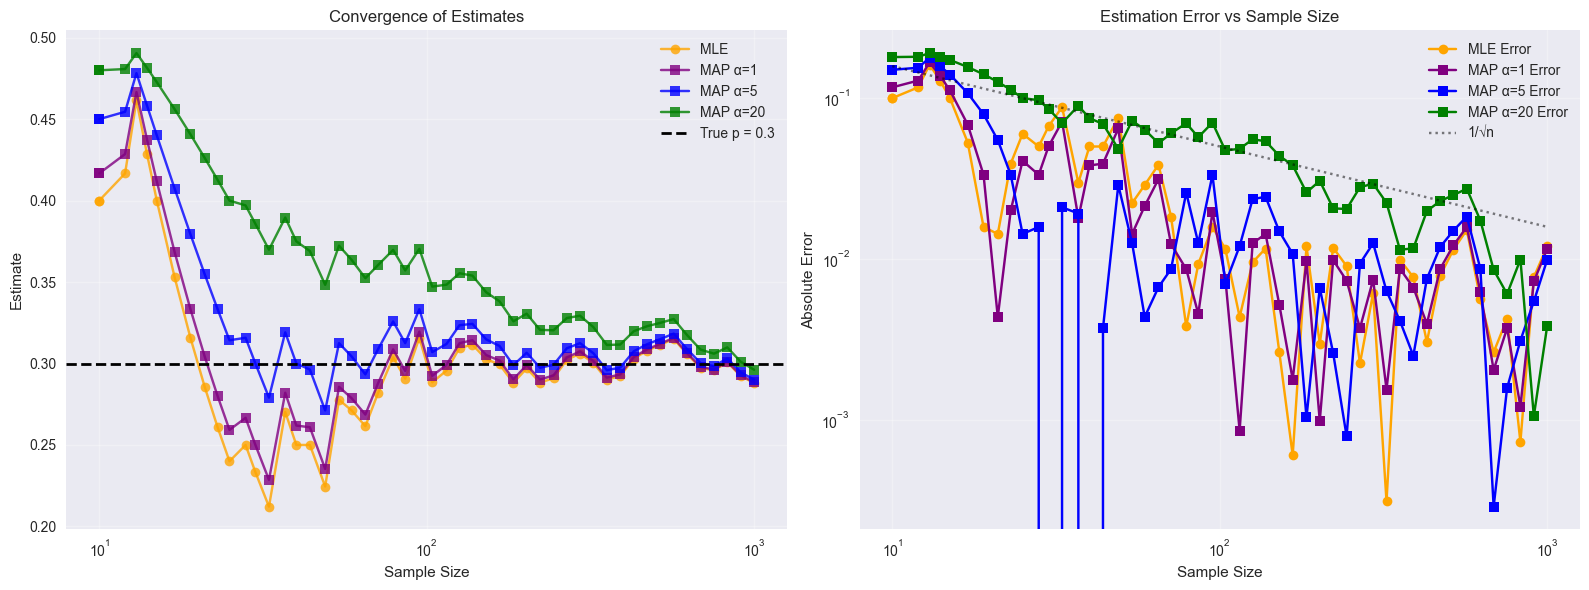

Convergence Analysis:
True probability: 0.3

Sample size where |estimate - true_p| < 0.05:
MLE: 19 samples
MAP (α=1): 19 samples
MAP (α=5): 23 samples
MAP (α=20): 49 samples


In [20]:
def convergence_analysis():
    """Analyze convergence properties of MLE and MAP."""
    
    np.random.seed(42)
    true_p = 0.3
    max_n = 1000
    
    # Different prior strengths
    priors = [(1, 1), (5, 5), (20, 20)]
    sample_sizes = np.logspace(1, 3, 50).astype(int)  # 10 to 1000
    
    results = {'n': sample_sizes}
    
    # Generate data once
    all_tosses = np.random.binomial(1, true_p, max_n)
    
    for alpha, beta in priors:
        mle_estimates = []
        map_estimates = []
        
        for n in sample_sizes:
            tosses = all_tosses[:n]
            n_heads = np.sum(tosses)
            
            mle = n_heads / n
            map_est = (alpha + n_heads) / (alpha + beta + n)
            
            mle_estimates.append(mle)
            map_estimates.append(map_est)
        
        results[f'MLE'] = mle_estimates
        results[f'MAP_a{alpha}'] = map_estimates
    
    # Plot convergence
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Estimates vs sample size
    ax1.semilogx(sample_sizes, results['MLE'], 'o-', color='orange', label='MLE', alpha=0.8)
    
    colors = ['purple', 'blue', 'green']
    for i, (alpha, beta) in enumerate(priors):
        ax1.semilogx(sample_sizes, results[f'MAP_a{alpha}'], 's-', 
                    color=colors[i], label=f'MAP α={alpha}', alpha=0.8)
    
    ax1.axhline(true_p, color='black', linestyle='--', linewidth=2, label=f'True p = {true_p}')
    ax1.set_xlabel('Sample Size')
    ax1.set_ylabel('Estimate')
    ax1.set_title('Convergence of Estimates')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Errors vs sample size
    mle_errors = [abs(est - true_p) for est in results['MLE']]
    ax2.loglog(sample_sizes, mle_errors, 'o-', color='orange', label='MLE Error')
    
    for i, (alpha, beta) in enumerate(priors):
        map_errors = [abs(est - true_p) for est in results[f'MAP_a{alpha}']]
        ax2.loglog(sample_sizes, map_errors, 's-', 
                  color=colors[i], label=f'MAP α={alpha} Error')
    
    # Add theoretical 1/sqrt(n) line
    theoretical = 0.5 / np.sqrt(sample_sizes)
    ax2.loglog(sample_sizes, theoretical, 'k:', alpha=0.5, label='1/√n')
    
    ax2.set_xlabel('Sample Size')
    ax2.set_ylabel('Absolute Error')
    ax2.set_title('Estimation Error vs Sample Size')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Find convergence points
    print("Convergence Analysis:")
    print(f"True probability: {true_p}")
    print("\nSample size where |estimate - true_p| < 0.05:")
    
    mle_convergence = next((n for n, err in zip(sample_sizes, mle_errors) if err < 0.05), None)
    print(f"MLE: {mle_convergence if mle_convergence else '>1000'} samples")
    
    for i, (alpha, beta) in enumerate(priors):
        map_errors = [abs(est - true_p) for est in results[f'MAP_a{alpha}']]
        map_convergence = next((n for n, err in zip(sample_sizes, map_errors) if err < 0.05), None)
        print(f"MAP (α={alpha}): {map_convergence if map_convergence else '>1000'} samples")

convergence_analysis()

## Summary and Key Takeaways

### When to Use MLE vs MAP

| Criterion | MLE | MAP |
|-----------|-----|-----|
| **Sample Size** | Large samples | Small to medium samples |
| **Prior Knowledge** | No strong beliefs | Have reasonable prior beliefs |
| **Extreme Estimates** | Can give 0/1 estimates | Regularized, more conservative |
| **Computational** | Simple formula | Need to specify prior |
| **Objective** | Pure data-driven | Incorporate domain knowledge |

### Key Insights

1. **MLE Advantages**:
   - Simple and intuitive: just count and divide
   - Asymptotically optimal (converges to true value)
   - No subjective prior specification needed

2. **MLE Limitations**:
   - Can give extreme estimates (0 or 1) with small samples
   - Ignores prior knowledge
   - Can be unstable with limited data

3. **MAP Advantages**:
   - Incorporates prior knowledge
   - More stable with small samples
   - Provides natural regularization
   - Full Bayesian framework (uncertainty quantification)

4. **MAP Considerations**:
   - Requires prior specification (can be subjective)
   - More computationally complex
   - Prior choice affects results

### Practical Guidelines

- **Use MLE when**: You have lots of data and no strong prior beliefs
- **Use MAP when**: You have limited data or meaningful prior information
- **Both converge** to the same value as sample size increases
- **Bayesian approach** (MAP) provides richer information (credible intervals)

### Connection to Machine Learning

This coin toss example directly relates to:
- **Naive Bayes**: Estimating class probabilities and feature likelihoods
- **Logistic Regression**: MLE vs regularized (MAP) estimation
- **Neural Networks**: Dropout as Bayesian approximation
- **A/B Testing**: Estimating conversion rates
- **Recommendation Systems**: User preference estimation

## Reflection Questions

1. **Philosophical Question**: Is the "true" probability of a coin an inherent property or a useful mathematical abstraction? How does this affect your choice between MLE and MAP?

2. **Practical Scenario**: You're analyzing click-through rates for a new ad campaign. After 100 views, you observe 3 clicks. Your boss wants to know if the campaign is working. How would you use MLE vs MAP approaches, and what would you tell your boss?

3. **Prior Elicitation**: How would you choose prior parameters for estimating:
   - Free-throw percentage for a professional basketball player?
   - Success rate of a new medical treatment?
   - Probability of rain tomorrow?

4. **Computational Considerations**: In what scenarios might the computational simplicity of MLE outweigh the theoretical advantages of MAP?